# 1-Data cleaning and preprocessing

The goal of this notebook is to prepare the dataset for the different NLP tasks of the project.

More specifically we will:
- load and merge all excel files,
- inspect the dataset structure,
- clean the review text for NLP tasks,
- create a supervised subset,
- inspect the existing correction and translation columns,
- regenerate corrected and translated texts on a subset of the data.

1) Imports

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


2) Define the data path

In [2]:
data_path = "../data/raw"

3) List all excel files 

In [3]:
files = os.listdir(data_path)

excel_files = [f for f in files if f.endswith(".xlsx")]
excel_files


['avis_33_traduit.xlsx',
 'avis_34_traduit.xlsx',
 'avis_21_traduit.xlsx',
 'avis_26_traduit.xlsx',
 'avis_10_traduit.xlsx',
 'avis_17_traduit.xlsx',
 'avis_27_traduit.xlsx',
 'avis_20_traduit.xlsx',
 'avis_35_traduit.xlsx',
 'avis_32_traduit.xlsx',
 'avis_16_traduit.xlsx',
 'avis_11_traduit.xlsx',
 'avis_7_traduit.xlsx',
 'avis_1_traduit.xlsx',
 'avis_6_traduit.xlsx',
 'avis_18_traduit.xlsx',
 'avis_4_traduit.xlsx',
 'avis_3_traduit.xlsx',
 'avis_29_traduit.xlsx',
 'avis_19_traduit.xlsx',
 'avis_2_traduit.xlsx',
 'avis_5_traduit.xlsx',
 'avis_28_traduit.xlsx',
 'avis_22_traduit.xlsx',
 'avis_25_traduit.xlsx',
 'avis_30_traduit.xlsx',
 'avis_13_traduit.xlsx',
 'avis_14_traduit.xlsx',
 'avis_8_traduit.xlsx',
 'avis_31_traduit.xlsx',
 'avis_24_traduit.xlsx',
 'avis_23_traduit.xlsx',
 'avis_15_traduit.xlsx',
 'avis_12_traduit.xlsx',
 'avis_9_traduit.xlsx']

4) Number of files found

In [4]:
len(excel_files)

35

5) Load and merge all excel files

In [5]:
dfs = []

for file in excel_files:
    path = os.path.join(data_path, file) 
    df_temp = pd.read_excel(path) 
    df_temp["source_file"] = file # we add a new column with the file name
    dfs.append(df_temp) 

df = pd.concat(dfs, ignore_index=True) 

6) Preview the dataset

In [6]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,source_file
0,NaN,estelle-51227,j'ai quitté mon ancien contrat d'assurance che...,Néoliane Santé,sante,test,12/01/2017,01/01/2017,I left my former insurance contract at General...,NaN,NaN,avis_33_traduit.xlsx
1,NaN,leadum-51107,j'ai souscrit à cette mutuelle l'année dernier...,Néoliane Santé,sante,test,09/01/2017,01/01/2017,I subscribed to this mutual a year last year a...,NaN,NaN,avis_33_traduit.xlsx
2,NaN,enora-49520,"Impossible d'avoir le bon service , ils raccro...",Néoliane Santé,sante,test,24/11/2016,01/11/2016,"Impossible to have the right service, they han...",NaN,NaN,avis_33_traduit.xlsx
3,NaN,bea-139295,Génération est une mutuelle très chère pour un...,Génération,sante,test,09/11/2021,01/11/2021,Generation is a very expensive mutual for a re...,NaN,NaN,avis_33_traduit.xlsx
4,NaN,anna-139192,je viens d apprendre que je suis radié... j ap...,Génération,sante,test,08/11/2021,01/11/2021,I just learned that I am struck off ... I call...,NaN,NaN,avis_33_traduit.xlsx


7) We check the dataset size to see if it was concatenate correctly 

In [7]:
df.shape

(34435, 12)

8) Display the columns names

In [8]:
df.columns.tolist()

['note',
 'auteur',
 'avis',
 'assureur',
 'produit',
 'type',
 'date_publication',
 'date_exp',
 'avis_en',
 'avis_cor',
 'avis_cor_en',
 'source_file']

9) Dataframe info

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
 11  source_file       34435 non-null  object 
dtypes: float64(1), object(11)
memory usage: 3.2+ MB


10) Missing values

In [10]:
df.isna().sum().sort_values(ascending=False)

avis_cor_en         34004
avis_cor            34000
note                10331
avis_en                 2
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
source_file             0
dtype: int64

The columns "avis_cor" and "avis_cor_en" already exist in the original dataset but they contain almost no data.

Instead of dropping them permanently, we keep them in mind and later regenerate them on a subset of the supervised data.

This is more consistent with the original dataset structure and with the project requirements on spelling correction and translation.

11) Remove exact duplicates

In [11]:
df = df.drop_duplicates().copy()
df.shape

(34434, 12)

12) We define a basic text cleaning fucntion for NLP 

We create a strongly normalized version of the reviews for NLP tasks such as:
- EDA,
- topic modeling,
- embeddings,
- classical machine learning.

This version is useful for NLP analysis but it is not ideal for spelling correction or translation because it removes punctuation and contractions. We will use it later.

In [13]:
def clean_text(text):
    text = str(text).lower() # we convert to string and lowercase
    text = re.sub(r"http\S+|www\S+", " ", text) # we remove all the URLs
    text = re.sub(r"\n|\r|\t", " ", text) 
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s]", " ", text) # we remove all the special characters except for letters, numbers and spaces
    text = re.sub(r"\s+", " ", text).strip() # we remove extra spaces
    return text

13) We create a cleaned review colum

In [16]:
df["avis_clean_fr"] = df["avis"].apply(clean_text)

14) We compare original vs cleaned text

In [17]:
df[["avis", "avis_clean_fr"]].head(10)

,avis,avis_clean_fr
0,j'ai quitté mon ancien contrat d'assurance che...,j ai quitté mon ancien contrat d assurance che...
1,j'ai souscrit à cette mutuelle l'année dernier...,j ai souscrit à cette mutuelle l année dernier...
2,"Impossible d'avoir le bon service , ils raccro...",impossible d avoir le bon service ils raccroch...
3,Génération est une mutuelle très chère pour un...,génération est une mutuelle très chère pour un...
4,je viens d apprendre que je suis radié... j ap...,je viens d apprendre que je suis radié j appel...
5,"Service client très accessible, temps d’attent...",service client très accessible temps d attente...
6,Réactivité des professionnels à l écoute \nJe ...,réactivité des professionnels à l écoute je tr...
7,Catastrophique en relation client. Depuis des ...,catastrophique en relation client depuis des m...
8,jai pris contacte avec vos service se jour pou...,jai pris contacte avec vos service se jour pou...
9,Je suis toujours dans l'attente du rembourseme...,je suis toujours dans l attente du rembourseme...


15) We remove empty cleaned reviews

In [18]:
df = df[df["avis_clean"].str.len() > 0].copy() 
df.shape

(34433, 14)

16) We check the distribution of ratings 

In [19]:
df["note"].value_counts().sort_index()

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64

We can add a visualization

/var/folders/h5/fthz7w1d6l1_w09sqsgml2vm0000gn/T/ipykernel_1572/3227922330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="note", data=df, palette="viridis")


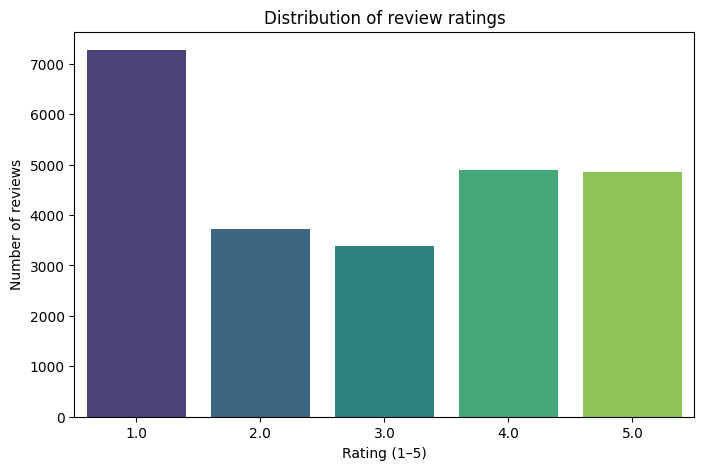

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(x="note", data=df, palette="viridis")

plt.title("Distribution of review ratings")
plt.xlabel("Rating (1–5)")
plt.ylabel("Number of reviews")

plt.show()

17) We convert the date columns in datetime

In [21]:
for col in ["date_publication", "date_exp"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

df[["date_publication", "date_exp"]].head()

,date_publication,date_exp
0,2017-01-12,2017-01-01
1,2017-01-09,2017-01-01
2,2016-11-24,2016-11-01
3,2021-11-09,2021-11-01
4,2021-11-08,2021-11-01


18) Labeled subset for supervised learning

We previously saw that note has many missing values so we wil create a labeled subset for supervised learning with only the rows containing a non null value

In [22]:
df_supervised = df.dropna(subset=["note"]).copy() 
df_supervised["note"] = df_supervised["note"].astype(int) 

df_supervised.shape

(24104, 14)

19. Create a subset for advanced preprocessing

The original dataset already contains the columns `avis_cor` and `avis_cor_en`, but they are almost empty.

We therefore regenerate these columns on a subset of the supervised data.

Due to computational constraints, this advanced preprocessing is applied to a sample of the data rather than the full dataset.

In [23]:
df_subset = df_supervised.sample(3000, random_state=42).copy()
df_subset.shape

(3000, 14)

20. Define a light cleaning function

For spelling correction and translation, we do not want to clean the text too aggressively.

We therefore create a lightly cleaned version of the reviews ("avis_light") that preserves most of the original sentence structure.

This version is more suitable for spelling correction and translation.

In [26]:
def light_clean(text):
    #text = str(text).lower() #sometimes the the uppercase can be useful for the model, so we keep it as is(the strat of sentences and the proper nouns)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\n|\r|\t", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_subset["avis_light"] = df_subset["avis"].apply(light_clean)

21. Let's compare original vs light clean text 

In [27]:
df_subset[["avis", "avis_light"]].head(10) 

,avis,avis_light
11980,La personne au téléphone pendant ma pause de m...,La personne au téléphone pendant ma pause de m...
16657,"Je suis sociétaire depuis des années, aucun si...","Je suis sociétaire depuis des années, aucun si..."
7776,je suis insatisfait du service.\nje souscrit u...,je suis insatisfait du service. je souscrit un...
33041,"Très satisfait de cette assurance, d'autant pl...","Très satisfait de cette assurance, d'autant pl..."
2199,bonjour je suis tres satisfaites de vous serv...,bonjour je suis tres satisfaites de vous servi...
20637,Attention pour le placement assurance retraite...,Attention pour le placement assurance retraite...
26666,Quand tout va bien... rien à dire ! Mais quan...,Quand tout va bien... rien à dire ! Mais quand...
30347,"Simple pratique, de supers prix\nPersonnel dis...","Simple pratique, de supers prix Personnel disp..."
26514,Je n'ai pas pus payer en plusieurs fois pour c...,Je n'ai pas pus payer en plusieurs fois pour c...
5434,"Simple et rapide\nPrix honnête, conseillers ef...","Simple et rapide Prix honnête, conseillers eff..."


#### Spelling correction

We apply spelling correction to the lightly cleaned french reviews.

The goal is not to produce perfect linguistic correction but to create a cleaner version of the text for experimentation in downstream tasks.

In [28]:
%pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.


In [29]:
from spellchecker import SpellChecker

spell = SpellChecker(language="fr")

def correct_text(text):
    words = str(text).split()
    corrected = [spell.correction(w) if spell.correction(w) else w for w in words]
    return " ".join(corrected)

df_subset["avis_cor"] = df_subset["avis_light"].apply(correct_text) 

#### Translation

We generate English translations for both the lightly cleaned reviews and the corrected reviews.

This allows us to compare original french text, corrected french text, translated english text and corrected and translated english text.

In [30]:
%pip install deep-translator

Note: you may need to restart the kernel to use updated packages.


In [31]:
from deep_translator import GoogleTranslator

def translate_text(text):
    try:
        return GoogleTranslator(source="fr", target="en").translate(text)
    except:
        return text

/Users/koralie/Desktop/nlp_project2/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [32]:
#df_subset["avis_en"] = df_subset["avis_light"].apply(translate_text)
df_subset["avis_cor_en"] = df_subset["avis_cor"].apply(translate_text)

21. Define a cleaned version for NLP comparison

After generating corrected and translated texts, we apply the same NLP cleaning function in order to compare the different text versions under a common preprocessing pipeline.

In [33]:
df_subset["avis_clean"] = df_subset["avis"].apply(clean_text) # we apply the clean_text function to the original "avis" 
df_subset["avis_cor_clean"] = df_subset["avis_cor"].apply(clean_text) # we apply the clean_text function to the corrected "avis_cor"
df_subset["avis_en_clean"] = df_subset["avis_en"].apply(clean_text) # the same for "avis_en"
df_subset["avis_cor_en_clean"] = df_subset["avis_cor_en"].apply(clean_text) # the same for "avis_cor_en"

22. Verify the enriched subset

In [34]:
df_subset[["avis","avis_light","avis_cor","avis_en","avis_cor_en","avis_clean","avis_cor_clean","avis_en_clean","avis_cor_en_clean"]].head()

,avis,avis_light,avis_cor,avis_en,avis_cor_en,avis_clean,avis_cor_clean,avis_en_clean,avis_cor_en_clean
11980,La personne au téléphone pendant ma pause de m...,La personne au téléphone pendant ma pause de m...,La personne au téléphone pendant ma pause de m...,The person on the phone during my lunch break ...,The person on the phone during my lunch break ...,la personne au téléphone pendant ma pause de m...,la personne au téléphone pendant ma pause de m...,the person on the phone during my lunch break ...,the person on the phone during my lunch break ...
16657,"Je suis sociétaire depuis des années, aucun si...","Je suis sociétaire depuis des années, aucun si...",Je suis sociétaire depuis des années aucun sin...,"I have been a member for years, no claim decla...","I have been a member for years, no claims repo...",je suis sociétaire depuis des années aucun sin...,je suis sociétaire depuis des années aucun sin...,i have been a member for years no claim declar...,i have been a member for years no claims repor...
7776,je suis insatisfait du service.\nje souscrit u...,je suis insatisfait du service. je souscrit un...,je suis insatisfait du service je souscrit un ...,I am dissatisfied with the service.\nI take ou...,I am dissatisfied with the service I take out ...,je suis insatisfait du service je souscrit un ...,je suis insatisfait du service je souscrit un ...,i am dissatisfied with the service i take out ...,i am dissatisfied with the service i take out ...
33041,"Très satisfait de cette assurance, d'autant pl...","Très satisfait de cette assurance, d'autant pl...",Très satisfait de cette assurance autant plus ...,"Very satisfied with this insurance, all the mo...","Very satisfied with this insurance, especially...",très satisfait de cette assurance d autant plu...,très satisfait de cette assurance autant plus ...,very satisfied with this insurance all the mor...,very satisfied with this insurance especially ...
2199,bonjour je suis tres satisfaites de vous serv...,bonjour je suis tres satisfaites de vous servi...,bonjour je suis très satisfaites de vous servi...,hello I am very satisfied with you service and...,hello I am very satisfied with your service an...,bonjour je suis tres satisfaites de vous servi...,bonjour je suis très satisfaites de vous servi...,hello i am very satisfied with you service and...,hello i am very satisfied with your service an...


23. Save processed datasets

We save three dataset versions:

- the full cleaned dataset,
- the supervised dataset,
- the enriched subset with correction and translation

In [36]:
df.to_csv("../data/processed/reviews_clean.csv", index=False)
df_supervised.to_csv("../data/processed/reviews_supervised.csv", index=False)
df_subset.to_csv("../data/processed/reviews_subset_enriched.csv", index=False)

24. Final check

In [37]:
print("Full cleaned dataset shape:", df.shape)
print("Supervised dataset shape:", df_supervised.shape)
print("Enriched subset shape:", df_subset.shape)

Full cleaned dataset shape: (34433, 14)
Supervised dataset shape: (24104, 14)
Enriched subset shape: (3000, 18)


### Dataset versions used in the project

Different versions of the dataset were created during the preprocessing phase.

- `reviews_clean.csv` is used as the main dataset for all NLP tasks (EDA, topic modeling, embeddings, and supervised learning).
- `reviews_supervised.csv` is used for supervised learning tasks with available ratings.
- `reviews_subset_enriched.csv` is used only for experimentation with spelling correction and translation on a subset of the data.


### Choice of Language for the NLP Pipeline

During the project, we considered whether we should perform all subsequent analyses using the translated english dataset or continue working with the original french data.The project instructions do not explicitly require the use of english for the subsequent NLP tasks. Therefore, we carefully evaluated both options before making a decision.
After reflection, we decided to continue using the original french dataset for the main pipeline.

This decision was motivated by several reasons:

- First, working in french allows us to use the full dataset, whereas the translated and corrected data is only available for a subset of reviews due to computational constraints.
- Second, automatic translation tools (ex google translate) may introduce errors or alter the original meaning of the reviews, which can negatively impact the quality of NLP models.
- Third, modern NLP models (such as multilingual or french specific models) are capable of processing french text directly, making translation unnecessary for most tasks.

Therefore, we chose to keep the original language and use the cleaned and corrected French text (`avis_clean`) for our supervised learning experiments.


For completeness and transparency, we also provide the code for the English version (based on translated reviews) as commented sections in the notebook, allowing comparison between both approaches.